## Part 1 — Connect, and measure your machine

### Step 1.1 — Imports

**What this does.** Loads the libraries this notebook needs.

**Why these.** `httpx` makes HTTP requests — that is how we talk to the model, which is a
server running on your own machine. `numpy` and `pandas` hold results. `matplotlib` draws
one chart at the end. `hashlib` lets us fingerprint outputs so we can compare them exactly
rather than by eye. `ThreadPoolExecutor` sends several requests at once in Part 3.

**What you should see.** `imports ok` and nothing else.

**If it fails.** Your notebook is running outside the project environment. Close it and
relaunch with `uv run jupyter lab` from inside `aids-course`.

# Session 1 — Lab

## Before you start

You should have finished the **Setup Runbook** and seen `ALL CLEAR` from `doctor.py`.
If not, go back to it — nothing below will work, and the instructor would much rather
unblock you now than in Session 4.

Launch this notebook from inside your project folder:

```
cd aids-course
uv run jupyter lab
```

---

## What this lab is for

In the lecture we established that `temperature = 0` means **greedy decoding**: at every
position, take the token with the highest logit. An argmax is a deterministic function of
its input.

So the question is:

> **Is the output of greedy decoding a deterministic function of the prompt?**

You voted at the start of the session. Now you are going to measure it on your own machine,
and produce a more precise answer than yes or no — which matters, because every number you
compute with one of these models for the rest of the course inherits whatever you find.

### How this notebook is written

Each step has the same four parts, so you always know where you are:

| | |
|---|---|
| **What this does** | the mechanical action |
| **Why it is written this way** | the reasoning — do not skip these, they are the lab |
| **What you should see** | so you can tell working from broken |
| **How to read it** | what the output means |

**Run every cell in order.** Shift+Enter runs a cell and moves on.

Four cells are marked ✅ **CHECKPOINT**. Each prints a number. **Post every one to the
shared sheet.**

### Time budget

| Part | Minutes |
|---|---|
| 1. Connect, and measure your machine | 10 |
| 2. Two ways to call the same model | 8 |
| 3. The determinism experiment | 25 |
| 4. Your model card | 7 |

---

In [1]:
import os
import json
import time
import hashlib
import platform
import statistics
from concurrent.futures import ThreadPoolExecutor

import httpx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("imports ok")

imports ok


### Step 1.2 — Point at your local model

**What this does.** Sets the address of the model server and the name of the model, then
asks the server what it has.

**Why it is written this way.**

- `OLLAMA` is a URL on `127.0.0.1` — that is your own machine, the loopback address.
  **Nothing in this notebook sends data anywhere.** That is the whole point of running
  locally, and for several of you it is the difference between being able to use these
  methods on your research data and not.
- We read both values from environment variables with a fallback (`os.environ.get`). That
  way you can change the model for the whole notebook in one place, and later sessions can
  set `COURSE_MODEL` once and have every notebook agree.
- `/api/tags` is the endpoint that lists installed models. We call it first because a clear
  error now ("you don't have that model") is much better than a confusing one later.

**What you should see.** Your server address, a list of your installed models, and `ready.`

**If `MODEL` is not in the list**, the cell tells you what to do. Either edit the line, or
pull the model in a terminal.

In [2]:
OLLAMA = os.environ.get("OLLAMA_HOST", "http://127.0.0.1:11434")

# >>> EDIT THIS LINE if you pulled a different model <<<
MODEL = os.environ.get("COURSE_MODEL", "qwen3:1.7b")

r = httpx.get(f"{OLLAMA}/api/tags", timeout=10)
available = [m["name"] for m in r.json().get("models", [])]

print(f"server   : {OLLAMA}")
print(f"available: {available}")
print(f"using    : {MODEL}")

if MODEL not in available:
    print(f"\n!! {MODEL} is not in the list above.")
    print("!! Either edit MODEL to one of the available names,")
    print(f"!! or run in a terminal:  ollama pull {MODEL}")
else:
    print("\nready.")

server   : http://127.0.0.1:11434
available: ['qwen3:1.7b', 'qwen3:8b', 'qwen3:4b']
using    : qwen3:1.7b

ready.


### Step 1.3 — The one function this whole course uses

**What this does.** Wraps a single call to the model in a Python function.

**Why we are writing it by hand instead of using a library.** Every session in this course
calls a model through something shaped like this. Writing it once, in plain `httpx`, means:

- you can see exactly what goes over the wire — there is no hidden machinery;
- nothing breaks when a wrapper library reorganises its imports between Session 2 and
  Session 13;
- in Session 12, when a "tool call" turns out to be a JSON object inside one of these
  messages, you will already know what that means.

**Reading the function.** Three parts, and nothing else:

1. **`messages`** — the conversation, as a list of `{"role": ..., "content": ...}`
   dictionaries. `system` sets standing instructions; `user` is the prompt. This shape is
   an industry convention, not a law of nature, but everything uses it.

2. **`options`** — the sampling parameters from the lecture:
   - `temperature` — divides the logits before the softmax. `0` means greedy: take the
     argmax. This is the setting under test today.
   - `seed` — seeds the random number generator **used for sampling**. At `temperature=0`
     there is no sampling, so this should do nothing. You will verify that in the optional
     section.
   - `num_predict` — a cap on how many tokens to generate, so a runaway generation cannot
     hang your lab.

3. **The POST** — one HTTP request to your own machine. `stream=False` means "send the
   whole answer at once" rather than token by token, which keeps the code simple.

**Why it returns metadata too.** `eval_count` is how many tokens the model *produced*;
`prompt_eval_count` is how many it *read*. Dividing output tokens by wall-clock time gives
tokens per second, which is the number that tells you what is feasible on your hardware for
the rest of the term.

**What you should see.** A sentence defining a confounder, then a throughput line. On a
small model on CPU, expect roughly 10–40 tok/s. On a GPU, several hundred.

In [3]:
def llm(prompt, model=MODEL, system=None, temperature=0.0, seed=42,
        max_tokens=1024, base=OLLAMA, timeout=300.0):

    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})

    payload = {
        "model": model,
        "messages": messages,
        "stream": False,

        # Important for Qwen3
                "think": False,

        "options": {
            "temperature": temperature,
            "seed": seed,
            "num_predict": max_tokens,
        },
    }

    t0 = time.perf_counter()

    r = httpx.post(
        f"{base}/api/chat",
        json=payload,
        timeout=timeout
    )

    r.raise_for_status()
    d = r.json()

    wall = time.perf_counter() - t0

    meta = {
        "wall_s": wall,
        "out_tokens": d.get("eval_count") or 0,
        "in_tokens": d.get("prompt_eval_count") or 0,
        "tok_per_s": (d.get("eval_count") or 0) / wall if wall else 0.0,
    }

    return d["message"]["content"], meta


text, meta = llm("In one sentence: what is a confounder?")
print(text.strip())
print()
print(f"{meta['tok_per_s']:.1f} tok/s | {meta['out_tokens']} tokens out | {meta['wall_s']:.1f}s")

A confounder is a variable that influences both the independent variable and the dependent variable, thereby distorting the apparent relationship between them in a statistical study.

7.3 tok/s | 31 tokens out | 4.3s


> **If that took more than 60 seconds**, your model is too large for your machine. Stop,
> open a terminal, run `ollama pull qwen3:1.7b`, then set `MODEL = "qwen3:1.7b"` in Step 1.2
> and re-run from there. You will be much happier for the rest of the course.

> **If the answer looks wrong or rambling**, that is expected from a small model and is not
> a problem today. We are testing reproducibility, not quality.

### Step 1.4 — ✅ CHECKPOINT A

**What this does.** Runs three short generations and takes the median throughput.

**Why three and why the median.** A single timing is noisy — the first call may include
loading the model into memory, and background processes on your laptop come and go. Three
runs and a median is the cheapest defence against reporting a number that happens to be an
outlier. This is the same instinct you would apply to any measurement; it is worth noticing
that it applies here too.

**Why we care about this number at all.** The spread across this cohort will be roughly
50× between the fastest and slowest machine. That range determines what is feasible in
every later lab — a two-minute cell for one person is a forty-minute cell for another —
and it is why the labs are written with CPU paths throughout.

**What you should see.** Three similar numbers, then a summary block.

**Post the summary line to the shared sheet.**

In [4]:
runs = []

for i in range(3):
    text, m = llm(
        "Count from 1 to 15, comma separated.",
        seed=i,
        max_tokens=10000
    )

    runs.append(m["tok_per_s"])

    print(f"Run {i+1}")
    print(f"  response: {text.strip()}")
    print(f"  speed   : {m['tok_per_s']:6.1f} tok/s")
    print()

THROUGHPUT = statistics.median(runs)

print("=" * 58)
print(f"  CHECKPOINT A — median throughput: {THROUGHPUT:.1f} tok/s")
print(f"  machine: {platform.system()} {platform.machine()}, {os.cpu_count()} cores")
print(f"  model  : {MODEL}")
print("=" * 58)
print("\n  ^ post this to the shared sheet")

Run 1
  response: 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
  speed   :   21.0 tok/s

Run 2
  response: 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
  speed   :   23.0 tok/s

Run 3
  response: 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
  speed   :   23.2 tok/s

  CHECKPOINT A — median throughput: 23.0 tok/s
  machine: Windows AMD64, 14 cores
  model  : qwen3:1.7b

  ^ post this to the shared sheet


---

## Part 2 — Two ways to call the same model

**What this part is for.** You are about to call the same model, on the same machine, two
different ways. They *should* agree. Checking whether they do is a habit worth forming:
the places where two interfaces to the same thing disagree are where silent bugs live.

### Step 2.1 — Through the command line

**What this does.** Runs the `ollama` command-line program from inside Python and captures
what it prints.

**Why.** The CLI is a completely separate code path to our `httpx` call, but it talks to
the same server and loads the same weights. If the two disagree, something other than the
model is making a decision — and that something is usually a default parameter you did not
set.

**What you should see.** A sentence about confounders, or a message saying the CLI is not
on your PATH.

**If it is not on your PATH**, skip it — this step is instructive, not essential. (On macOS
the CLI is installed the first time you launch the Ollama app.)

```
--think=false     Disable thinking entirely
--hidethinking    Allow thinking, but don't show it
```

In [5]:
import subprocess

PROMPT = "In one sentence: what is a confounder?"

try:
    out = subprocess.run(
        ["ollama", "run", MODEL, "--hidethinking", PROMPT],
        capture_output=True,
        text=True,
        timeout=1024,
    )

    cli_text = out.stdout.strip()
    print("CLI  :", cli_text)

except FileNotFoundError:
    cli_text = None
    print("ollama CLI not on PATH — skip this step, it is not essential")

except subprocess.TimeoutExpired:
    cli_text = None
    print("CLI timed out — skip it")

CLI  : A confounder is a variable that is associated with both the independent and
and dependent variables and is not properly controlled in the analysis, lea
leading to a distorted estimate of the effect of the independent variable o
on the dependent variable.


### Step 2.2 — ✅ CHECKPOINT B — compare them

**What this does.** Runs the same prompt through our HTTP function and compares the two
strings exactly.

**Why exact comparison.** Eyeballing two paragraphs and deciding they are "basically the
same" is how you miss this. We compare strings.

**What you should see.** Either `identical? True`, or `False` with an explanation.

**How to read it.** If they differ, the reason is almost certainly that the CLI applied its
own default sampling parameters while our call set `temperature=0, seed=42` explicitly.
Same model, same machine, different knobs.

**The lesson, which is bigger than this cell.** "Which model did you use?" is not enough
information to reproduce a result. Two people running "the same model" can get different
answers because one of them left a default in place.

**Post to the shared sheet: did yours agree, yes or no?** The room will be split, and that
split is the point.

In [6]:
http_text, _ = llm(PROMPT)

print("HTTP :", http_text.strip()[:200])
print()

if cli_text:
    same = cli_text.strip() == http_text.strip()
    print("=" * 58)
    print(f"  CHECKPOINT B — CLI and HTTP identical? {same}")
    print("=" * 58)
    if not same:
        print("\nThey differ — and this is worth noticing.")
        print("The CLI applies its own default sampling options; our HTTP call sets")
        print("temperature=0 and seed=42 explicitly. Same model, different knobs.")
        print("\nLesson: 'which model did you use' is not enough to reproduce a result.")
else:
    print("(CLI unavailable — record checkpoint B as 'not tested')")

HTTP : A confounder is a variable that influences both the independent variable and the dependent variable, thereby distorting the apparent relationship between them in a study or analysis.

  CHECKPOINT B — CLI and HTTP identical? False

They differ — and this is worth noticing.
The CLI applies its own default sampling options; our HTTP call sets
temperature=0 and seed=42 explicitly. Same model, different knobs.

Lesson: 'which model did you use' is not enough to reproduce a result.


> A third path would be loading the weights directly with `transformers`, which disagrees
> with both. That is a 2 GB download, so it is homework (Stage 6), and we come back to it in
> Session 4.

---

## Part 3 — The determinism experiment

### The hypothesis under test

From the lecture:

> With `temperature = 0` and a fixed seed, generation is a deterministic function of the prompt.

**Write down your prediction now**, before running anything. Do you expect 12 identical
outputs, or not?

### Why anyone would doubt it

Greedy decoding takes an `argmax` over logits. Those logits come out of enormous
floating-point sums — matrix multiplications adding thousands of products per output value.

**Floating-point addition is not associative.** Each operation rounds to the nearest
representable number, so `(a + b) + c` and `a + (b + c)` can differ in the last bits. Run
this yourself:

```python
(0.1 + 0.2) + 0.3 == 0.1 + (0.2 + 0.3)   # False
```

Hardware does not perform those enormous sums in one fixed order. It splits them across
threads, accumulates partial sums, and combines them in a reduction tree whose shape depends
on the kernel chosen, the tensor dimensions, and **how many sequences are being processed
together** — the batch.

So the logits wobble in the last bits between runs. An `argmax` does not care about a wobble
that small — **unless the top two tokens are nearly tied.** When they are, the wobble picks
the token. And because generation is autoregressive, every token after that is conditioned
on a different prefix, so the outputs do not differ slightly; they diverge completely.

### The design of this part

Three tests, deliberately, because the first two depend on luck and the third does not:

| Step | Test | Fires when |
|---|---|---|
| 3.1–3.2 | Repeat the same call 12 times | Something varies the batch. On an idle laptop, often nothing does |
| 3.3 | Repeat under concurrent load | More likely — 8 requests at once changes batching |
| 3.4–3.5 | Measure branch points; perturb whitespace | **Always.** These do not depend on observing a flip |

---

### Step 3.1 — Run the same prompt 12 times

**What this does.** Sends one prompt, twelve times, with identical parameters, and groups
the outputs by an exact fingerprint.

**Why a hash instead of comparing strings.** With twelve outputs we want to count *distinct*
ones. Hashing each output to a short fingerprint and grouping by it does that in one line,
and it compares exactly rather than approximately.

**Why this prompt.** It asks for a list of six items — long enough that there are many
token decisions, and open-ended enough that several are genuine near-ties. A prompt with one
obvious answer would be stable no matter what.

**What you should see.** A progress counter, then the number of distinct outputs.

**How long.** About two minutes on a small CPU model.

In [7]:
import os
import json
import time
import hashlib
import platform
import statistics
from concurrent.futures import ThreadPoolExecutor

import httpx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OLLAMA = os.environ.get("OLLAMA_HOST", "http://127.0.0.1:11434")

# >>> EDIT THIS LINE if you pulled a different model <<<
MODEL = os.environ.get("COURSE_MODEL", "qwen3:1.7b")

r = httpx.get(f"{OLLAMA}/api/tags", timeout=10)
available = [m["name"] for m in r.json().get("models", [])]

print(f"server   : {OLLAMA}")
print(f"available: {available}")
print(f"using    : {MODEL}")

if MODEL not in available:
    print(f"\n!! {MODEL} is not in the list above.")
    print("!! Either edit MODEL to one of the available names,")
    print(f"!! or run in a terminal:  ollama pull {MODEL}")
else:
    print("\nready.")

def llm(prompt, model=MODEL, system=None, temperature=0.0, seed=42,
        max_tokens=1024, base=OLLAMA, timeout=300.0):

    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})

    payload = {
        "model": model,
        "messages": messages,
        "stream": False,

        # Important for Qwen3
        "think": False,

        "options": {
            "temperature": temperature,
            "seed": seed,
            "num_predict": max_tokens,
        },
    }

    t0 = time.perf_counter()

    r = httpx.post(
        f"{base}/api/chat",
        json=payload,
        timeout=timeout
    )

    r.raise_for_status()
    d = r.json()

    wall = time.perf_counter() - t0

    meta = {
        "wall_s": wall,
        "out_tokens": d.get("eval_count") or 0,
        "in_tokens": d.get("prompt_eval_count") or 0,
        "tok_per_s": (d.get("eval_count") or 0) / wall if wall else 0.0,
    }

    return d["message"]["content"], meta

server   : http://127.0.0.1:11434
available: ['qwen3:1.7b', 'qwen3:8b', 'qwen3:4b']
using    : qwen3:1.7b

ready.


In [8]:
PROBE = ("List exactly 6 potential confounders in a study of coffee consumption "
         "and heart disease. Number them 1-6. One short line each.")
N_RUNS = 12

outputs = []
t0 = time.time()
for i in range(N_RUNS):
    txt, _ = llm(PROBE, temperature=0.0, seed=42, max_tokens=4096)
    outputs.append(txt)
    print(f"  {i+1}/{N_RUNS}", end="\r", flush=True)

print(f"\ndone in {time.time()-t0:.0f}s")

# fingerprint each output so we can count distinct ones exactly
digest = lambda s: hashlib.sha256(s.encode()).hexdigest()[:10]
groups = {}
for o in outputs:
    groups.setdefault(digest(o), []).append(o)

print(f"\n{N_RUNS} runs at temperature=0, seed=42  ->  {len(groups)} distinct output(s)")
for h, g in groups.items():
    print(f"   {h}  x{len(g)}")

SEQUENTIAL_DISTINCT = len(groups)

  12/12
done in 67s

12 runs at temperature=0, seed=42  ->  2 distinct output(s)
   b31d51a3ab  x1
   9c75664b04  x11


### Step 3.2 — If you got more than one, find where they split

**What this does.** Takes two different outputs and finds the first character position at
which they disagree.

**Why position rather than, say, edit distance.** An edit distance would tell you *that* the
outputs differ. The position tells you *where the decision was made*. Everything before it
is identical because it was computed from identical inputs; everything after it differs
because the model is conditioning on a different prefix. That is autoregression, and seeing
it directly is the point of this cell.

**What you should see.** Either a divergence point with the two continuations printed, or a
message saying all twelve were identical.

**If all twelve were identical — read that message carefully.** It is a legitimate result,
not a failure, and the cell explains why.

In [9]:
def first_difference(a, b):
    """Index of the first character at which two strings differ."""
    for i, (x, y) in enumerate(zip(a, b)):
        if x != y:
            return i
    return None if len(a) == len(b) else min(len(a), len(b))

if len(groups) > 1:
    a, b = [g[0] for g in list(groups.values())[:2]]
    i = first_difference(a, b)
    print(f"the two outputs are identical for {i} characters, then diverge:\n")
    print(f"  common : ...{a[max(0, i-70):i]}")
    print(f"  then A : {a[i:i+45]!r}")
    print(f"  then B : {b[i:i+45]!r}")
    print(f"\nEverything after character {i} is generated from a different prefix,")
    print("which is why one flipped token changes the whole rest of the answer.")
else:
    print("All 12 runs were identical on your machine.")
    print()
    print("That is a legitimate result, and it is common: a single client talking to an")
    print("idle local server. Nothing is varying the batch composition, so the arithmetic")
    print("groups the same way every time and the argmax never flips.")
    print()
    print("Do NOT conclude that temperature=0 is deterministic in general.")
    print("Continue to 3.3 and 3.4 — the effect is real, it just is not visible here yet.")

the two outputs are identical for 612 characters, then diverge:

  common : ...nsumption and heart disease risk.  
6. Alcohol consumption - Alcohol c
  then A : 'an increase heart disease risk and may intera'
  then B : 'onsumption can interact with coffee and incre'

Everything after character 612 is generated from a different prefix,
which is why one flipped token changes the whole rest of the answer.


### Step 3.3 — Add concurrent load

**What this does.** Sends eight identical requests at the same time, using threads, instead
of one after another.

**Why this is the interesting condition.** Sequential requests on an idle server are the
*easy* case — nothing varies. Concurrency is what actually changes batch composition, and
batch composition is what changes the grouping of the floating-point sums.

**Why it matters beyond this notebook.** This is not an artificial stress test. It is what
happens when:

- your server is shared with anyone else;
- you parallelise your own evaluation loop to save time (**this one catches researchers
  constantly**);
- you use a hosted API, where you are batched with strangers and cannot see it.

**What you should see.** A timing, then a comparison of sequential versus concurrent
distinct counts.

**How to read it.** If concurrent > sequential, you have observed the effect directly. If
not, your runtime may be serialising the requests rather than truly batching them — which
is itself a fact about your deployment worth knowing.

In [10]:
def one_call(_):
    return llm(PROBE, temperature=0.0, seed=42, max_tokens=4096)[0]

t0 = time.time()
with ThreadPoolExecutor(max_workers=8) as ex:
    concurrent_out = list(ex.map(one_call, range(8)))
print(f"8 concurrent requests in {time.time()-t0:.0f}s")

conc_groups = {}
for o in concurrent_out:
    conc_groups.setdefault(digest(o), []).append(o)

CONCURRENT_DISTINCT = len(conc_groups)

print(f"\nsequential : {SEQUENTIAL_DISTINCT} distinct")
print(f"concurrent : {CONCURRENT_DISTINCT} distinct")

8 concurrent requests in 41s

sequential : 2 distinct
concurrent : 1 distinct


### Step 3.4 — The measurement that works regardless

**The problem with steps 3.1–3.3.** Whether you personally observe a flip is partly luck. A
lab whose lesson depends on luck is a bad lab. So we now measure the underlying fragility
**directly**, in a way that gives a number on every machine.

**The idea.** A generation is a sequence of argmax decisions. Some are comfortable — the
winner beats the runner-up by a mile. Others are near-ties, where a tiny numerical wobble
would flip the outcome. **We want to count the near-ties**, because that is the number of
coin-flips hiding inside a generation you believed was deterministic.

**How we estimate them.** We cannot read the model's internal logits through this API, so we
use resampling instead: run the same prompt at `temperature = 1` several times (which *does*
sample), and see where the samples leave the greedy path.

**The subtlety that makes this correct — and it is the methodological point of the step.**

A naive version would check each position independently: "at position 3, how many samples
match the greedy token?" **That is wrong.** Once a sample diverges at position 3, every later
position is misaligned — it is a different sentence — so it counts as a disagreement
everywhere, and you dramatically overstate the fragility.

The correct question conditions on survival: *of the samples that have followed the greedy
path all the way to position i, what fraction are still on it after position i?*

That makes this a **survival curve**, and the drop at each step is the **hazard of diverging
there**.

**What you should see.** The greedy output, a count of branch points, and the first one
located in the text.

**How to read it.** One branch point means the generation was essentially determined, with a
single genuine decision. Many branch points means a fragile generation — many places where a
numerical wobble would change everything downstream.

In [11]:
SHORT = "Name the single most important confounder in coffee-and-heart-disease studies. One sentence."
K = 10

# K samples at temperature=1 (so sampling is ON), plus the greedy output to compare against
samples = [llm(SHORT, temperature=1.0, seed=s, max_tokens=4096)[0] for s in range(K)]
greedy, _ = llm(SHORT, temperature=0.0, seed=42, max_tokens=4096)

tokens = lambda s: s.split()          # word-level is a good enough proxy here
g_toks = tokens(greedy)
s_toks = [tokens(s) for s in samples]

# Conditional survival: a sample is "alive" at position i only if it matched the
# greedy path at EVERY position before i. This is the conditioning that makes the
# measurement correct.
alive = list(range(K))
rows = []
for i, gt in enumerate(g_toks):
    if not alive:
        break
    survivors = [j for j in alive if i < len(s_toks[j]) and s_toks[j][i] == gt]
    rows.append({
        "position": i,
        "token": gt,
        "at_risk": len(alive),                        # samples still on the path
        "survived": len(survivors),
        "hazard": 1 - len(survivors) / len(alive),    # P(diverge here | survived to here)
        "survival": len(survivors) / K,               # fraction of ALL samples still on path
    })
    alive = survivors

surv = pd.DataFrame(rows)
BRANCHES = surv[surv.hazard > 0]

print(f"greedy output ({len(g_toks)} words):\n  {greedy.strip()[:200]}\n")
print(f"positions where at least one sample left the greedy path: "
      f"{len(BRANCHES)} of {len(surv)} examined")
if len(BRANCHES):
    print("\nthe branch points:")
    print(BRANCHES[["position", "token", "at_risk", "survived", "hazard"]]
          .head(8).to_string(index=False))
    first = int(BRANCHES.position.iloc[0])
    print(f"\nfirst branch at word {first}: "
          f"{'…' + ' '.join(g_toks[max(0,first-4):first])} [{g_toks[first]}] ←")
else:
    print("\nNo branching in 10 samples — a very confident generation.")
    print("Try a longer or more open-ended prompt and re-run.")

FRAGILE = BRANCHES

greedy output (25 words):
  The single most important confounder in coffee-and-heart-disease studies is **alcohol consumption**, as it is often associated with coffee drinking and can independently affect heart health.

positions where at least one sample left the greedy path: 4 of 25 examined

the branch points:
 position      token  at_risk  survived   hazard
        9  **alcohol       10         4 0.600000
       14      often        4         3 0.250000
       15 associated        3         2 0.333333
       18   drinking        2         1 0.500000

first branch at word 9: …in coffee-and-heart-disease studies is [**alcohol] ←


**Now plot it.**

**What this does.** Draws the survival curve, with each branch point marked.

**How to read the chart.** The line starts at 1.0 — all samples begin on the greedy path.
Each vertical drop is a position where some left it. A curve that stays high is a
generation that was essentially determined; a curve that falls away early is one where the
model was making genuine choices that a numerical wobble could have made differently.

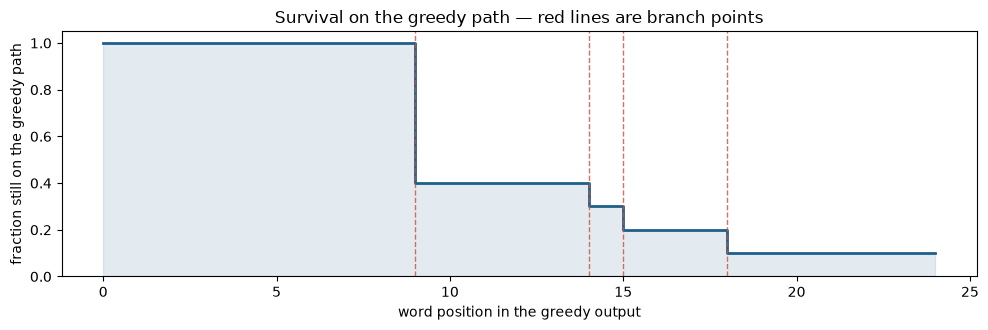

Half the samples have left the greedy path by word 9.

Each red line is a position where the model was close to choosing something else.
A numerical wobble at any one of them changes everything downstream.


In [12]:
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.step(surv.position, surv.survival, where="post", color="#1f5f8b", lw=2)
ax.fill_between(surv.position, surv.survival, step="post", alpha=.12, color="#1f5f8b")
for _, r in BRANCHES.iterrows():
    ax.axvline(r.position, color="#c94f3d", ls="--", lw=1, alpha=.8)
ax.set_xlabel("word position in the greedy output")
ax.set_ylabel("fraction still on the greedy path")
ax.set_ylim(0, 1.05)
ax.set_title("Survival on the greedy path — red lines are branch points")
plt.tight_layout()
plt.show()

if len(BRANCHES):
    below = (surv.survival <= .5)
    where = int(surv.loc[below.idxmax(), "position"]) if below.any() else None
    print(f"Half the samples have left the greedy path by word {where}."
          if where is not None else
          "More than half the samples stayed on the greedy path throughout.")
print("\nEach red line is a position where the model was close to choosing something else.")
print("A numerical wobble at any one of them changes everything downstream.")

### Step 3.5 — The perturbation that always works

**What this does.** Sends five prompts that differ only in whitespace, and compares the
outputs.

**Why this is the most important cell in the notebook.** Steps 3.1–3.4 measure fragility
that *might* be triggered. This one triggers something on every machine, every time — and
what it demonstrates is arguably worse.

**Why whitespace changes anything at all.** Remember from the lecture: the model does not
read characters, it reads **tokens**, and whitespace is part of a token. `"the"` and `" the"`
are different tokens with different embeddings. Adding a trailing space can change how the
whole prompt is split, which changes the input sequence, which changes every computation
downstream.

**The point.** These five prompts are *semantically identical*. No human reader would call
them different. No paper would report the difference. No reviewer would ask.

**What you should see.** Five rows, with a count of distinct outputs at the bottom. Expect
2 or more.

**Post that count to the shared sheet.**

In [13]:
variants = {
    "original"        : SHORT,
    "trailing space"  : SHORT + " ",
    "trailing newline": SHORT + "\n",
    "doubled space"   : SHORT.replace(" the ", "  the ", 1),
    "leading space"   : " " + SHORT,
}

rows = []
for name, p in variants.items():
    txt, _ = llm(p, temperature=0.0, seed=42, max_tokens=4096)
    rows.append({"variant": name, "hash": digest(txt), "output": txt.strip()[:72]})

pert = pd.DataFrame(rows)
n_distinct = pert.hash.nunique()

print(pert.to_string(index=False))
print()
print(f"{len(variants)} semantically identical prompts  ->  {n_distinct} distinct outputs")
PERTURBATION_DISTINCT = n_distinct

         variant       hash                                                                   output
        original ee13248a3c The single most important confounder in coffee-and-heart-disease studies
  trailing space 3527fd8861 The single most important confounder in coffee-and-heart-disease studies
trailing newline e2095a42e4 The single most important confounder in coffee-and-heart-disease studies
   doubled space 83015f3cab The single most important confounder in coffee-and-heart-disease studies
   leading space ee13248a3c The single most important confounder in coffee-and-heart-disease studies

5 semantically identical prompts  ->  4 distinct outputs


### Step 3.6 — ✅ CHECKPOINT C

**Post all four numbers to the shared sheet**, whatever they are — including
"everything was identical". That is a result, and the pattern across the room is what we
discuss.

In [14]:
print("=" * 58)
print("  CHECKPOINT C — determinism")
print("=" * 58)
print(f"  sequential runs, distinct outputs   : {SEQUENTIAL_DISTINCT} / {N_RUNS}")
print(f"  concurrent runs, distinct outputs   : {CONCURRENT_DISTINCT} / 8")
print(f"  branch points in the generation     : {len(FRAGILE)} of {len(surv)} words")
print(f"  whitespace variants, distinct       : {PERTURBATION_DISTINCT} / {len(variants)}")
print("=" * 58)
print("\n  ^ post all four to the shared sheet")

  CHECKPOINT C — determinism
  sequential runs, distinct outputs   : 2 / 12
  concurrent runs, distinct outputs   : 1 / 8
  branch points in the generation     : 4 of 25 words
  whitespace variants, distinct       : 4 / 5

  ^ post all four to the shared sheet


### What to take from Part 3

These are the operating rules for the rest of the course. Write them down.

**1. `temperature = 0` is not a reproducibility statement.** It constrains the sampler — it
does not pin the arithmetic underneath. Determinism is a property of your whole deployment:
model, quantisation, server, batch composition, hardware. Not of one parameter.

**2. Report the configuration, not the setting.** "We used `temperature=0`" is not
reproducible. Model tag, quantisation level, digest, server version and hardware are. That
is what Part 4 is for.

**3. A number computed from model output needs an error bar over runs**, not only over
items. Session 2 builds the harness that does this properly.

**4. Prompt whitespace is an uncontrolled variable.** If that seems absurd, that is the
correct reaction. Session 2 measures how far it can move a result — and the answer is often
further than the gap between two different models.

> **Two minutes with your breakout partner.** Which step of your own research pipeline would
> break if it silently produced a different answer one run in twenty? Would you notice?

---

## Part 4 — Your model card

### Step 4.1 — Generate it

**What this does.** Collects everything needed to reproduce today's numbers into one JSON
file, and saves it.

**Why this exists.** In Session 14 your final paper has to state what produced your results.
"We used a local language model" is not enough; neither is "we used `qwen3:1.7b`", because
that tag can point at different weights on different dates and different quantisations on
different machines. What makes a result reproducible is the full configuration.

**What goes in, and why each piece:**

| Field | Why |
|---|---|
| `model_tag` | Which model — necessary but not sufficient |
| `quantization` | Two people with the same tag can have different weights |
| `digest` | An exact content fingerprint of what you actually ran |
| `sampling` | The parameters, since defaults differ between interfaces |
| `hardware` | Because the arithmetic depends on it |
| `measured` | Your own determinism numbers, so a reader knows the variability |

**What you should see.** A JSON block, and a file written to your project folder.

**Keep this file.** Paste this block into every notebook from here on.

In [15]:
import datetime
from pathlib import Path

def model_card(model=MODEL, base=OLLAMA):
    card = {
        "recorded_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds"),
        "model_tag": model,
        "sampling": {"temperature": 0.0, "seed": 42},
        "hardware": {
            "os": f"{platform.system()} {platform.release()}",
            "arch": platform.machine(),
            "cpu_cores": os.cpu_count(),
        },
        "measured": {
            "tok_per_s": round(THROUGHPUT, 1),
            "sequential_distinct": SEQUENTIAL_DISTINCT,
            "concurrent_distinct": CONCURRENT_DISTINCT,
            "branch_points": int(len(FRAGILE)),
            "whitespace_variants_distinct": PERTURBATION_DISTINCT,
        },
        "caveat": ("temperature=0 is not bit-reproducible under varying batch "
                   "composition; see measured.concurrent_distinct"),
    }
    # /api/show returns the model's own metadata — quantisation, size, digest
    try:
        d = httpx.post(f"{base}/api/show", json={"model": model}, timeout=30).json()
        det = d.get("details", {})
        card["quantization"] = det.get("quantization_level")
        card["parameter_size"] = det.get("parameter_size")
        card["family"] = det.get("family")
        card["digest"] = (d.get("digest") or "")[:16]
    except Exception as e:
        card["show_error"] = str(e)[:80]
    return card

CARD = model_card()
Path("model_card.json").write_text(json.dumps(CARD, indent=2))
print(json.dumps(CARD, indent=2))

{
  "recorded_utc": "2026-09-25T14:14:37+00:00",
  "model_tag": "qwen3:1.7b",
  "sampling": {
    "temperature": 0.0,
    "seed": 42
  },
  "hardware": {
    "os": "Windows 11",
    "arch": "AMD64",
    "cpu_cores": 14
  },
  "measured": {
    "tok_per_s": 23.0,
    "sequential_distinct": 2,
    "concurrent_distinct": 1,
    "branch_points": 4,
    "whitespace_variants_distinct": 4
  },
  "caveat": "temperature=0 is not bit-reproducible under varying batch composition; see measured.concurrent_distinct",
  "quantization": "Q4_K_M",
  "parameter_size": "2.0B",
  "family": "qwen3",
  "digest": ""
}


### Step 4.2 — ✅ CHECKPOINT D

**Post your quantisation level and parameter size.**

**Why this is a checkpoint at all.** Everyone in this room typed a very similar
`ollama pull` command. Not everyone is running the same thing — tags move, defaults differ,
and platforms resolve differently. Seeing that on the shared sheet is the most direct
possible argument for recording provenance.

In [16]:
print("=" * 58)
print("  CHECKPOINT D — provenance")
print("=" * 58)
print(f"  model        : {CARD['model_tag']}")
print(f"  parameters   : {CARD.get('parameter_size', 'unknown')}")
print(f"  quantisation : {CARD.get('quantization', 'unknown')}")
print(f"  digest       : {CARD.get('digest', 'unknown')}")
print("=" * 58)
print("\n  model_card.json saved. Keep it — Session 14 asks for it.")

  CHECKPOINT D — provenance
  model        : qwen3:1.7b
  parameters   : 2.0B
  quantisation : Q4_K_M
  digest       : 

  model_card.json saved. Keep it — Session 14 asks for it.


---

## Part 5 — Research hook

**Write one paragraph and submit it before you leave.**

> Name one step of your current research pipeline that is a candidate for a language model,
> and state what would break if that step were non-deterministic.

Be specific on both halves:

- **Not** "text processing" — *"classifying the 4,000 free-text responses in my survey."*
- **Not** "results would vary" — *"the coefficient I report would move, and I would not know
  by how much."*

This paragraph is the seed of your Week 7 project proposal, so it is worth five real minutes.

---

## Optional — if you finished early

### A. Does the seed actually do anything?

**What this tests.** The lecture claimed that at `temperature = 0` the seed is irrelevant —
there is no sampling, so there is nothing to seed. This cell checks that claim.

**What you should see.** One distinct output across three seeds at `temperature = 0`, and
probably more than one at `temperature = 1`.

**If the seed DOES change the output at temperature 0** on your machine, something in your
stack is not doing what it claims. Report it to the room — that is a genuinely interesting
finding and exactly the kind of thing this course is about noticing.

In [17]:
rows = []
for temp in (0.0, 1.0):
    for seed in (1, 2, 3):
        txt, _ = llm(SHORT, temperature=temp, seed=seed, max_tokens=4096)
        rows.append({"temperature": temp, "seed": seed, "hash": digest(txt)})

seeds_df = pd.DataFrame(rows)
print(seeds_df.to_string(index=False))
print()
for temp, g in seeds_df.groupby("temperature"):
    print(f"temperature={temp}: {g.hash.nunique()} distinct output(s) across 3 seeds")
print("\nExpected: 1 distinct at temperature=0 (no sampling, so nothing to seed),")
print("more than 1 at temperature=1 (sampling, and the seed controls the draw).")

 temperature  seed       hash
         0.0     1 ee13248a3c
         0.0     2 ee13248a3c
         0.0     3 ee13248a3c
         1.0     1 97a09c107c
         1.0     2 ee13248a3c
         1.0     3 545dd93ff9

temperature=0.0: 1 distinct output(s) across 3 seeds
temperature=1.0: 3 distinct output(s) across 3 seeds

Expected: 1 distinct at temperature=0 (no sampling, so nothing to seed),
more than 1 at temperature=1 (sampling, and the seed controls the draw).


### B. Does a bigger model change the conclusion?

**What this tests.** Whether model size affects accuracy on questions with checkable
answers — and at what cost in speed.

**How to use it.** Pull a second model first, then set `SECOND_MODEL` and re-run:

```
ollama pull qwen3:4b
```

**What you should see.** An accuracy and throughput comparison across two models.

**How to read it — carefully.** Four questions is not an evaluation; it is an anecdote with
a percentage sign. Session 10 covers how many items you actually need to detect a difference
of a given size. The answer is considerably more than four.

In [18]:
SECOND_MODEL = None   # e.g. "qwen3:4b" — set it after pulling, then re-run

TASKS = [
    ("What is 17 * 23? Reply with only the number.", "391"),
    ("What is 144 / 12? Reply with only the number.", "12"),
    ("Capital of Kazakhstan? One word.", "astana"),
    ("How many days in a leap year? Only the number.", "366"),
]

if SECOND_MODEL:
    rows = []
    for m in (MODEL, SECOND_MODEL):
        for prompt, gold in TASKS:
            txt, meta = llm(prompt, model=m, max_tokens=4096)
            rows.append({"model": m, "correct": gold.lower() in txt.lower(),
                         "tok_per_s": meta["tok_per_s"]})
    comp = pd.DataFrame(rows)
    print(comp.groupby("model").agg(accuracy=("correct", "mean"),
                                    tok_per_s=("tok_per_s", "mean")).round(2).to_string())
    print("\nFour questions is not an evaluation — it is an anecdote.")
    print("Session 10 covers how many items you actually need.")
else:
    print("Set SECOND_MODEL after pulling a second model.")

Set SECOND_MODEL after pulling a second model.


---

## Before you close the notebook

- [ ] Four checkpoint numbers posted to the shared sheet
- [ ] `model_card.json` saved in your project folder
- [ ] Research-hook paragraph submitted
- [ ] **Homework — Stage 6 of the runbook**, on your home connection tonight:
      `uv add torch transformers sentence-transformers scikit-learn seaborn statsmodels pydantic tenacity`
      then `uv lock`
- [ ] Reading: skim the Model Context Protocol architecture overview

### Next session

**LLM Mechanics, Steering & Structured Generation.**

We take Step 3.5 seriously. If a trailing space moves the output, how far does a *deliberate*
prompt change move it — and is that bigger or smaller than the difference between two
different models?

*(It is usually bigger. Which means a good number of published model comparisons are
actually prompt comparisons.)*

Bring a labelled classification task from your own work if you have one.